# Riskfolio-Lib Tutorial: 
<br><a href="https://www.kqzyfj.com/click-101360347-15150084?url=https%3A%2F%2Flink.springer.com%2Fbook%2F9783031843037" target="_blank">
<div>
<img src="https://raw.githubusercontent.com/dcajasn/Riskfolio-Lib/refs/heads/master/docs/source/_static/Button.png" height="40" />
</div>
<br>
</a>
<a href="https://www.paypal.com/ncp/payment/GN55W4UQ7VAMN" target="_blank">
<div>
<img src="https://raw.githubusercontent.com/dcajasn/Riskfolio-Lib/refs/heads/master/docs/source/_static/Button2.png" height="40" />
</div>
</a>

<br><a href='https://ko-fi.com/B0B833SXD' target='_blank'><img height='36' style='border:0px;height:36px;' src='https://cdn.ko-fi.com/cdn/kofi1.png?v=2' border='0' alt='Buy Me a Coffee at ko-fi.com' /></a> 
<br>
<br>__[Financionerioncios](https://financioneroncios.wordpress.com)__
<br>__[Orenji](https://www.linkedin.com/company/orenj-i)__
<br>__[Riskfolio-Lib](https://riskfolio-lib.readthedocs.io/en/latest/)__
<br>__[Dany Cajas](https://www.linkedin.com/in/dany-cajas/)__

## Tutorial 57: Mean Risk Optimization using Entropy Pooling

## 1. Downloading the data:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import warnings

warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.4%}'.format

# Date range
start = '2016-01-01'
end = '2019-12-30'

# Tickers of assets
assets = ['JCI', 'TGT', 'CMCSA', 'CPB', 'MO', 'APA', 'MRSH', 'JPM',
          'ZION', 'PSA', 'BAX', 'BMY', 'LUV', 'PCAR', 'TXT', 'TMO',
          'DE', 'MSFT', 'HPQ', 'SEE', 'VZ', 'CNP', 'NI', 'T', 'BA']
assets.sort()

# Downloading data
data = yf.download(assets, start = start, end = end, auto_adjust=False)
data = data.loc[:,('Adj Close', slice(None))]
data.columns = assets

[*********************100%***********************]  25 of 25 completed


In [2]:
# Calculating returns

Y = data[assets].pct_change().dropna()

display(Y.head())

,APA,BA,BAX,BMY,CMCSA,CNP,CPB,DE,HPQ,JCI,...,NI,PCAR,PSA,SEE,T,TGT,TMO,TXT,VZ,ZION
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-05,-2.0257%,0.4057%,0.4035%,1.9692%,0.0180%,0.9305%,0.3678%,0.5784%,0.9482%,-1.1953%,...,1.5881%,0.0212%,2.8236%,0.9758%,0.6987%,1.7539%,-0.1730%,0.2410%,1.3734%,-1.0857%
2016-01-06,-11.4863%,-1.5878%,0.2412%,-1.7556%,-0.7727%,-1.2473%,-0.1736%,-1.1239%,-3.5867%,-0.9551%,...,0.5547%,0.0212%,0.1592%,-1.5646%,0.3108%,-1.0155%,-0.7653%,-3.0048%,-0.9034%,-2.9145%
2016-01-07,-5.1389%,-4.1922%,-1.6573%,-2.7699%,-1.1046%,-1.9769%,-1.2207%,-0.8856%,-4.6059%,-2.5394%,...,-2.2066%,-3.0309%,-1.0410%,-3.1557%,-1.6148%,-0.2700%,-2.2845%,-2.0570%,-0.5492%,-3.0019%
2016-01-08,0.2736%,-2.2705%,-1.6037%,-2.5425%,0.1099%,-0.2241%,0.5706%,-1.6401%,-1.7641%,-0.1649%,...,-0.1539%,-1.1366%,-0.7308%,-0.1448%,0.0896%,-3.3839%,-0.1117%,-1.1387%,-0.9719%,-1.1253%
2016-01-11,-4.3383%,0.1692%,-1.6851%,-1.0215%,0.0915%,-1.1791%,0.5674%,0.5288%,0.6616%,0.0330%,...,1.6436%,0.0000%,0.9869%,-0.1451%,1.2224%,1.4570%,0.5367%,-0.4607%,0.5800%,-1.9919%


## 2. Estimating Optimal Portfolios

### 2.1 Calculating portfolios with historical estimates.

In [3]:
import riskfolio as rp

# Building the portfolio object
port = rp.Portfolio(returns=Y)

# Calculating optimal portfolio

# Select method and estimate input parameters:

method_mu='hist' # Method to estimate expected returns based on historical data.
method_cov='hist' # Method to estimate covariance matrix based on historical data.
method_kurt='hist' # Method to estimate covariance matrix based on historical data.

port.assets_stats(method_mu=method_mu,
                  method_cov=method_cov,
                  method_kurt=method_kurt)

# Estimate optimal portfolio:
model='Classic' # Could be Classic, BL, FM, BLFM and EP
obj = 'Sharpe' # Objective function, could be MinRisk, MaxRet, Utility or Sharpe
hist = True # Use historical scenarios for risk measures that depend on scenarios
rf = 0 # Risk free rate
l = 0 # Risk aversion factor, only useful when obj is 'Utility'

w_1 = port.optimization(model=model, rm='MV', obj=obj, rf=rf, l=l, hist=hist)

display(w_1.T)

w_2 = port.optimization(model=model, rm='KT', obj=obj, rf=rf, l=l, hist=hist)

display(w_2.T)

You must convert self.kurt to a positive definite matrix
You must convert self.skurt to a positive definite matrix


,APA,BA,BAX,BMY,CMCSA,CNP,CPB,DE,HPQ,JCI,...,NI,PCAR,PSA,SEE,T,TGT,TMO,TXT,VZ,ZION
weights,0.0000%,6.1589%,11.5019%,0.0000%,0.0000%,8.4807%,0.0000%,3.8193%,0.0000%,0.0000%,...,10.8265%,0.0000%,0.0000%,0.0000%,0.0000%,7.1804%,0.0000%,0.0000%,4.2740%,0.0000%


,APA,BA,BAX,BMY,CMCSA,CNP,CPB,DE,HPQ,JCI,...,NI,PCAR,PSA,SEE,T,TGT,TMO,TXT,VZ,ZION
weights,0.0000%,2.4797%,11.5162%,0.0000%,0.0000%,18.7961%,2.3483%,1.6420%,0.0000%,0.0000%,...,10.0735%,0.0000%,0.0000%,0.0000%,0.0000%,8.6050%,0.0000%,0.0000%,10.6000%,0.0000%


### 2.2 Plotting portfolio composition

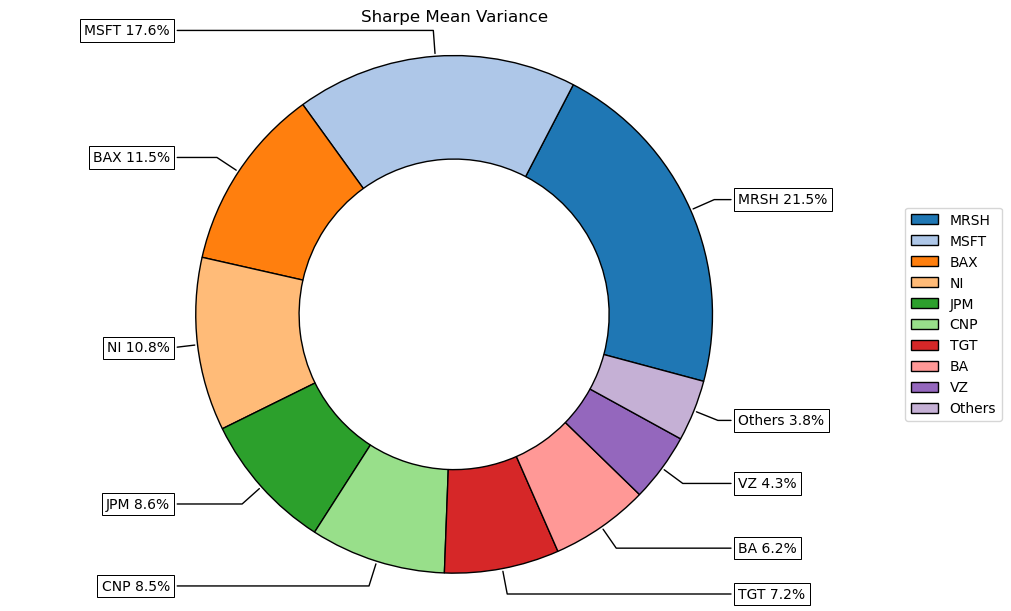

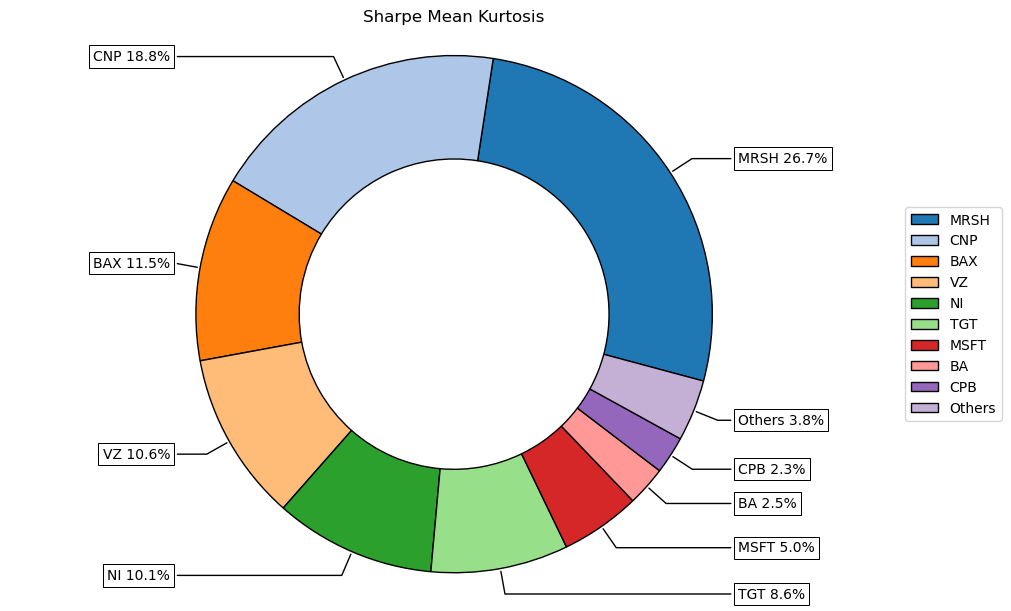

In [4]:
# Plotting the composition of portfolios

ax = rp.plot_pie(
    w=w_1,
    title='Sharpe Mean Variance',
    others=0.05,
    nrow=25,
    cmap="tab20",
    height=6,
    width=10,
    ax=None)
plt.show()

ax = rp.plot_pie(
    w=w_2,
    title='Sharpe Mean Kurtosis',
    others=0.05,
    nrow=25,
    cmap="tab20",
    height=6,
    width=10,
    ax=None)
plt.show()

### 2.3 Creating the views

In [5]:
asset_classes = {'Assets': ['JCI','TGT','CMCSA','CPB','MO','APA','MRSH','JPM',
                            'ZION','PSA','BAX','BMY','LUV','PCAR','TXT','TMO',
                            'DE','MSFT','HPQ','SEE','VZ','CNP','NI','T','BA'],
                 'Industry': ['Consumer Discretionary','Consumer Discretionary',
                              'Consumer Discretionary', 'Consumer Staples',
                              'Consumer Staples','Energy','Financials',
                              'Financials','Financials','Financials',
                              'Health Care','Health Care','Industrials','Industrials',
                              'Industrials','Health Care','Industrials',
                              'Information Technology','Information Technology',
                              'Materials','Telecommunications Services','Utilities',
                              'Utilities','Telecommunications Services','Financials']}

asset_classes = pd.DataFrame(asset_classes)
asset_classes = asset_classes.sort_values(by=['Assets'])

# Some of the views are incompatible, so we will disable some of them
views = {'Disabled': [False, True, False, True, False, True, False, True],
        'Kind':['Mean', 'Mean', 'Mean', 'Std', 'Cov', 'Corr', 'Skew', 'Kurt'],
        'Type': ['Assets', 'Assets', 'Assets', 'Assets', 'Assets', 'Assets',
                'Assets', 'Assets'],
        'Set': ['', '', '', '', '', '', '', ''],
        'Position': ['MSFT', 'MSFT', 'MSFT', 'MSFT', 'MSFT', 'MSFT', 'MSFT', 'MSFT'],
        'Sign': ['==', '>=', '>=', '==', '==', '==', '==', '=='],
        'Weight': [0.0008, 0.0008, 0.0008, 0.022, 0.0004, 0.9, 0.4, 4],
        'Type Relative': ['', 'Assets', 'Classes', 'Assets', 'Assets', 'Assets', '', ''],
        'Relative Set': ['', '', 'Industry', '', '', '', '', ''],
        'Relative': ['', 'BA', 'Financials', '', 'TXT', 'TXT', '', ''],
        'Factor': ['', '', '', '', '', '', '', '']
        }

views = pd.DataFrame(views)

display(views)


,Disabled,Kind,Type,Set,Position,Sign,Weight,Type Relative,Relative Set,Relative,Factor
0,False,Mean,Assets,,MSFT,==,0.0800%,,,,
1,True,Mean,Assets,,MSFT,>=,0.0800%,Assets,,BA,
2,False,Mean,Assets,,MSFT,>=,0.0800%,Classes,Industry,Financials,
3,True,Std,Assets,,MSFT,==,2.2000%,Assets,,,
4,False,Cov,Assets,,MSFT,==,0.0400%,Assets,,TXT,
5,True,Corr,Assets,,MSFT,==,90.0000%,Assets,,TXT,
6,False,Skew,Assets,,MSFT,==,40.0000%,,,,
7,True,Kurt,Assets,,MSFT,==,400.0000%,,,,


In [ ]:
# Creating the matrix of linear constraints views of entropy pooling model

P_eq, Q_eq, P_in, Q_in = rp.entropy_pooling_views(views, asset_classes, Y)

display(pd.DataFrame(P_eq))
display(pd.DataFrame(Q_eq))
display(pd.DataFrame(P_in))
display(pd.DataFrame(Q_in))

,0,1,2,3,4,5,6,7,8,9,...,993,994,995,996,997,998,999,1000,1001,1002
0,0.4562%,-1.8165%,-3.4782%,0.3067%,-0.0573%,0.9178%,-2.1599%,2.8466%,-3.9917%,-0.8433%,...,0.8418%,0.6471%,-0.5401%,-0.2069%,0.8681%,1.0918%,0.0000%,-0.0191%,0.8197%,0.1828%
1,0.0021%,0.0330%,0.1210%,0.0009%,0.0000%,0.0084%,0.0467%,0.0810%,0.1593%,0.0071%,...,0.0071%,0.0042%,0.0029%,0.0004%,0.0075%,0.0119%,0.0000%,0.0000%,0.0067%,0.0003%
2,0.0000%,-0.0006%,-0.0042%,0.0000%,-0.0000%,0.0001%,-0.0010%,0.0023%,-0.0064%,-0.0001%,...,0.0001%,0.0000%,-0.0000%,-0.0000%,0.0001%,0.0001%,0.0000%,-0.0000%,0.0001%,0.0000%


,0
0,0.0800%
1,0.0191%
2,0.0002%


,0,1,2,3,4,5,6,7,8,9,...,993,994,995,996,997,998,999,1000,1001,1002
0,-0.1728%,-0.4182%,-0.8709%,1.8593%,0.4312%,0.4660%,0.1313%,1.7471%,-1.8727%,-0.6722%,...,1.3760%,1.1389%,-0.7679%,-0.5462%,0.4375%,1.2323%,-0.1589%,0.1042%,0.5506%,0.1565%


,0
0,0.0800%


### 2.4 Calculating the portfolio with Entropy Pooling estimates

In [7]:
# Estimate Entropy Pooling inputs:

port.entropy_pooling_stats(P_eq, Q_eq, P_in, Q_in, higher_comoments=True)

# Estimate optimal portfolio:

model='EP' # Entropy Pooling
obj = 'Sharpe' # Objective function, could be MinRisk, MaxRet, Utility or Sharpe
hist = False # Use historical scenarios for risk measures that depend on scenarios

w_ep_1 = port.optimization(model=model, rm='MV', obj=obj, rf=rf, l=l, hist=hist)

display(w_ep_1.T)

w_ep_2 = port.optimization(model=model, rm='KT', obj=obj, rf=rf, l=l, hist=hist)

display(w_ep_2.T)

,APA,BA,BAX,BMY,CMCSA,CNP,CPB,DE,HPQ,JCI,...,NI,PCAR,PSA,SEE,T,TGT,TMO,TXT,VZ,ZION
weights,0.0000%,0.0000%,12.5030%,0.0000%,0.0000%,5.6218%,0.0000%,0.0000%,0.0000%,0.0000%,...,23.5714%,0.0000%,0.0000%,0.0000%,0.0000%,9.2537%,0.0000%,0.0000%,3.6643%,0.0000%


,APA,BA,BAX,BMY,CMCSA,CNP,CPB,DE,HPQ,JCI,...,NI,PCAR,PSA,SEE,T,TGT,TMO,TXT,VZ,ZION
weights,0.0000%,0.0000%,15.6442%,0.0000%,0.0000%,21.5240%,0.0000%,0.0000%,0.0000%,0.0000%,...,18.4196%,0.0000%,0.0000%,0.0000%,0.0000%,9.0641%,0.0000%,0.0000%,10.9316%,0.0000%


### 2.5 Plotting portfolio composition

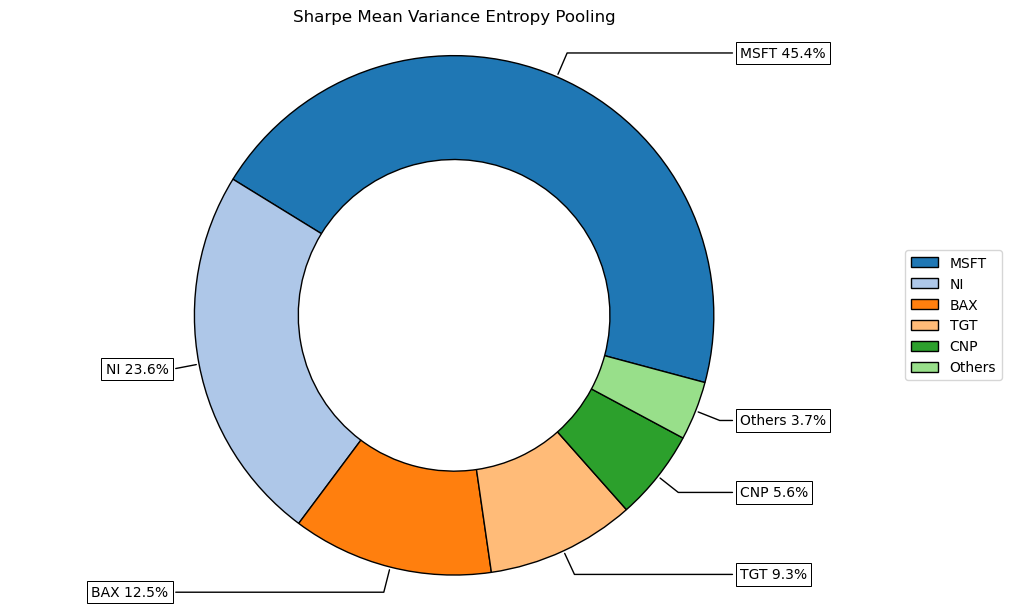

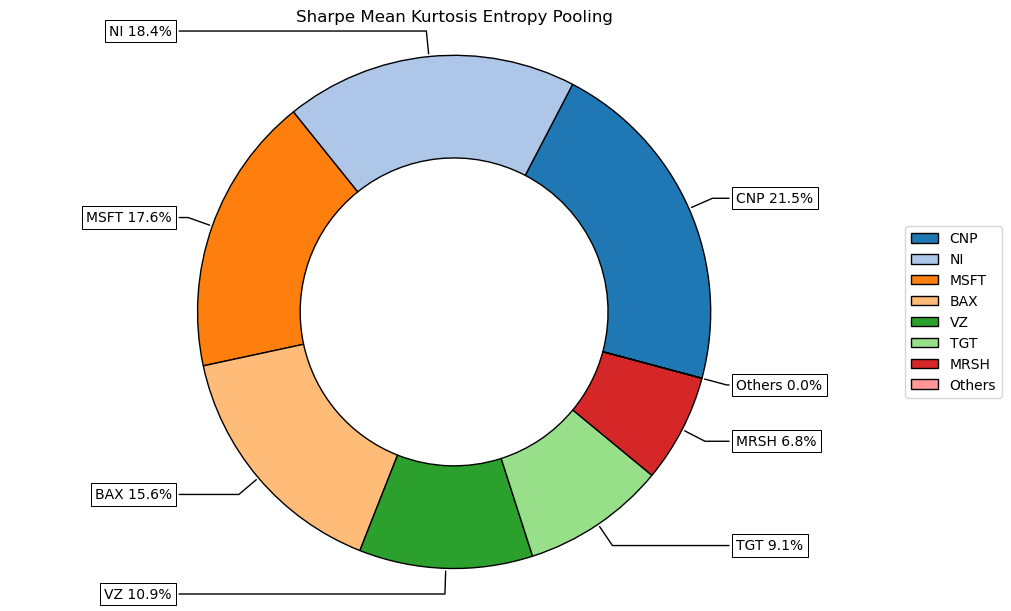

In [8]:
# Plotting the composition of portfolios

ax = rp.plot_pie(
    w=w_ep_1,
    title='Sharpe Mean Variance Entropy Pooling',
    others=0.05,
    nrow=25,
    cmap="tab20",
    height=6,
    width=10,
    ax=None)
plt.show()

ax = rp.plot_pie(
    w=w_ep_2,
    title='Sharpe Mean Kurtosis Entropy Pooling',
    others=0.05,
    nrow=25,
    cmap="tab20",
    height=6,
    width=10,
    ax=None)
plt.show()

In [9]:
# Comparing the weights of the different portfolios

Weights = pd.concat([w_1, w_2, w_ep_1, w_ep_2], axis=1)
Weights.columns = ['Sharpe MV', 'Sharpe MV EP','Sharpe KT', 'Sharpe KT EP']
display(Weights.style.format("{:.2%}").background_gradient(cmap='YlGn'))

,Sharpe MV,Sharpe MV EP,Sharpe KT,Sharpe KT EP
APA,0.00%,0.00%,0.00%,0.00%
BA,6.16%,2.48%,0.00%,0.00%
BAX,11.50%,11.52%,12.50%,15.64%
BMY,0.00%,0.00%,0.00%,0.00%
CMCSA,0.00%,0.00%,0.00%,0.00%
CNP,8.48%,18.80%,5.62%,21.52%
CPB,0.00%,2.35%,0.00%,0.00%
DE,3.82%,1.64%,0.00%,0.00%
HPQ,0.00%,0.00%,0.00%,0.00%
JCI,0.00%,0.00%,0.00%,0.00%


### 2.6 Plotting Efficient frontier

In [10]:
points = 50 # Number of points of the frontier

frontier = port.efficient_frontier(model=model, rm='MV', points=points, rf=rf, hist=hist)

display(frontier.T.head())

,APA,BA,BAX,BMY,CMCSA,CNP,CPB,DE,HPQ,JCI,...,NI,PCAR,PSA,SEE,T,TGT,TMO,TXT,VZ,ZION
0,0.0000%,0.0000%,5.0340%,4.6708%,2.2651%,6.7406%,3.6830%,0.0000%,0.0000%,2.5540%,...,11.5583%,0.0000%,14.9318%,0.0000%,7.0128%,4.0544%,0.0000%,0.0000%,8.2516%,0.0000%
1,0.0000%,0.0000%,8.8254%,1.6060%,2.1796%,8.6294%,2.9593%,1.0275%,0.0000%,1.0828%,...,15.1201%,0.0000%,8.4173%,0.0000%,7.5596%,5.9285%,0.0000%,0.0000%,9.3890%,0.0000%
2,0.0000%,0.0000%,9.9215%,0.3117%,1.8582%,9.3475%,2.6794%,1.3796%,0.0000%,0.3670%,...,16.5274%,0.0000%,5.6260%,0.0000%,7.8653%,6.6155%,0.0000%,0.0000%,9.8903%,0.0000%
3,0.0000%,0.0000%,10.6815%,0.0000%,1.3659%,9.8932%,2.3723%,1.4545%,0.0000%,0.0000%,...,17.9038%,0.0000%,2.9360%,0.0000%,7.9249%,7.1461%,0.0000%,0.0000%,10.4074%,0.0000%
4,0.0000%,0.0000%,11.2438%,0.0000%,0.5956%,10.3208%,1.8416%,1.1903%,0.0000%,0.0000%,...,19.4253%,0.0000%,0.0650%,0.0000%,7.5845%,7.5509%,0.0000%,0.0000%,10.8372%,0.0000%


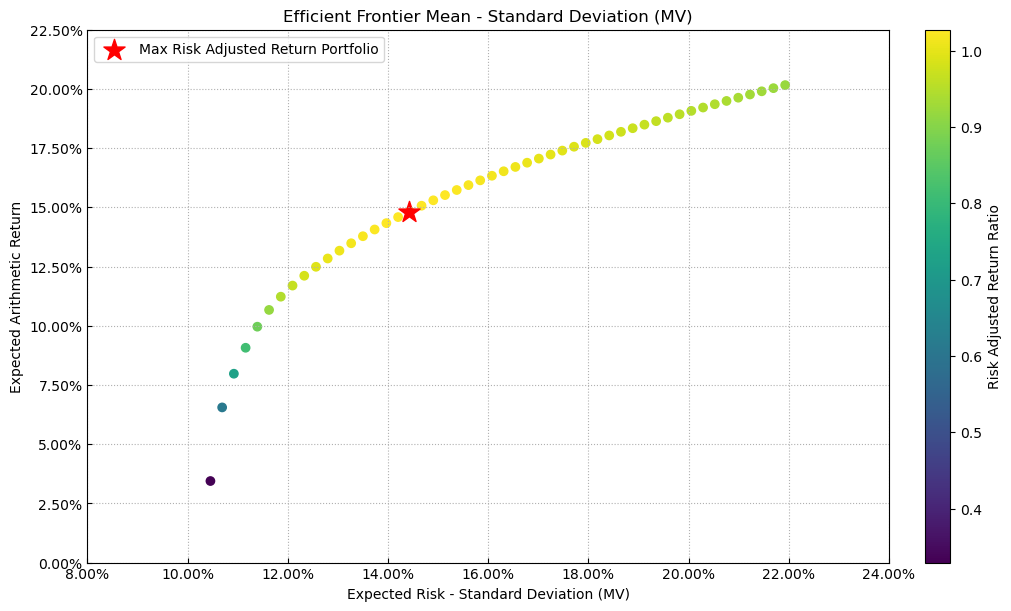

In [11]:
# Plotting the efficient frontier

label = 'Max Risk Adjusted Return Portfolio' # Title of point
mu = port.mu_ep # Expected returns of Entropy Pooling model
cov = port.cov_ep # Covariance matrix of Entropy Pooling model
returns = port.returns # Returns of the assets

ax = rp.plot_frontier(
    w_frontier=frontier,
    mu=mu,
    cov=cov,
    returns=returns,
    rm='MV',
    rf=rf,
    cmap='viridis',
    w=w_ep_1,
    label=label,
    marker='*',
    s=16,
    c='r',
    height=6,
    width=10,
    ax=None)

## 3. Estimating Entropy Pooling Mean Risk Portfolios

When we use risk measures different than Standard Deviation, Riskfolio-Lib only considers the vector of expected returns, and use historical returns to calculate risk measures.

### 3.1 Calculate Entropy Poolimg Portfolios for Several Risk Measures

In [12]:
# Risk Measures available:
#
# 'MV': Standard Deviation.
# 'MAD': Mean Absolute Deviation.
# 'MSV': Semi Standard Deviation.
# 'FLPM': First Lower Partial Moment (Omega Ratio).
# 'SLPM': Second Lower Partial Moment (Sortino Ratio).
# 'CVaR': Conditional Value at Risk.
# 'EVaR': Entropic Value at Risk.
# 'WR': Worst Realization (Minimax)
# 'MDD': Maximum Drawdown of uncompounded cumulative returns (Calmar Ratio).
# 'ADD': Average Drawdown of uncompounded cumulative returns.
# 'CDaR': Conditional Drawdown at Risk of uncompounded cumulative returns.
# 'EDaR': Entropic Drawdown at Risk of uncompounded cumulative returns.
# 'UCI': Ulcer Index of uncompounded cumulative returns.

rms = ['MV', 'MAD', 'MSV', 'FLPM', 'SLPM', 'CVaR',
       'EVaR', 'WR', 'MDD', 'ADD', 'CDaR', 'UCI', 'EDaR']

w_s = pd.DataFrame([])
port.alpha = 0.05

for i in rms:
    if i == 'MV':
        hist = False
    else:
        hist = True
    w = port.optimization(model=model, rm=i, obj=obj, rf=rf, l=l, hist=hist)
    w_s = pd.concat([w_s, w], axis=1)
    
w_s.columns = rms

In [13]:
display(w_s.style.format("{:.2%}").background_gradient(cmap='YlGn'))

,MV,MAD,MSV,FLPM,SLPM,CVaR,EVaR,WR,MDD,ADD,CDaR,UCI,EDaR
APA,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
BA,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
BAX,12.50%,8.81%,11.47%,9.07%,11.54%,9.54%,3.68%,0.00%,0.59%,6.92%,0.00%,4.93%,0.00%
BMY,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
CMCSA,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
CNP,5.62%,3.64%,8.44%,3.48%,8.67%,18.05%,18.86%,16.97%,39.53%,18.47%,35.19%,23.88%,36.38%
CPB,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
DE,0.00%,1.55%,0.00%,1.63%,0.00%,0.00%,0.00%,0.00%,0.00%,1.39%,0.19%,0.00%,0.00%
HPQ,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
JCI,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%


<Axes: >

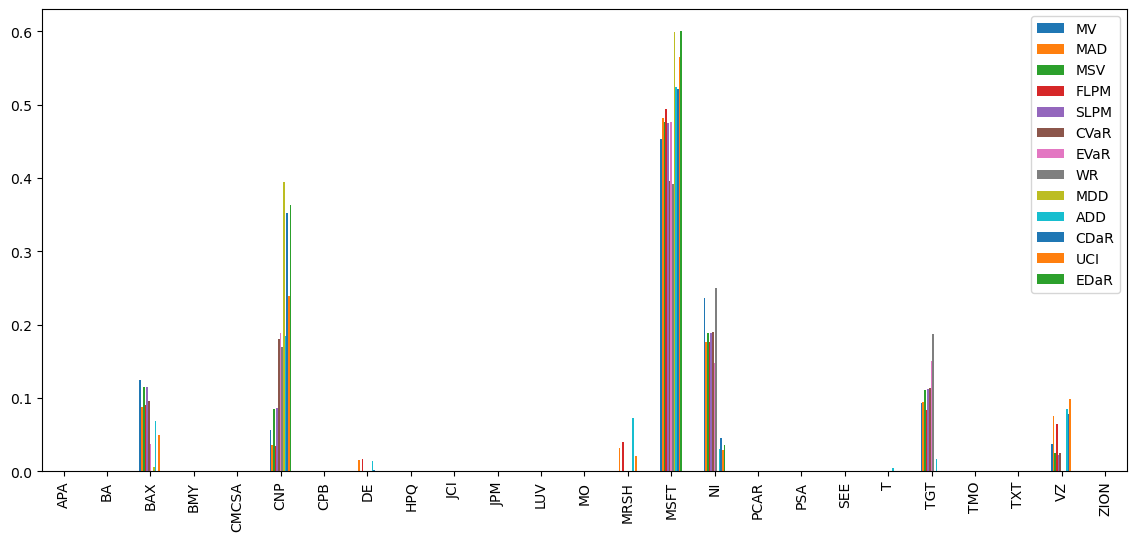

In [14]:
import matplotlib.pyplot as plt

# Plotting a comparison of assets weights for each portfolio

fig = plt.gcf()
fig.set_figwidth(14)
fig.set_figheight(6)
ax = fig.subplots(nrows=1, ncols=1)

w_s.plot.bar(ax=ax)